In [265]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.compose import make_column_selector as selector
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, adjusted_rand_score,
                             normalized_mutual_info_score,
                             homogeneity_completeness_v_measure, pairwise_distances)

In [266]:
df = pd.read_csv('dataset/online_retail_II.csv', encoding='ISO-8859-1')
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [267]:
df.drop_duplicates(inplace=True)

In [268]:
df.info()

<class 'pandas.DataFrame'>
Index: 1033036 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1033036 non-null  str    
 1   StockCode    1033036 non-null  str    
 2   Description  1028761 non-null  str    
 3   Quantity     1033036 non-null  int64  
 4   InvoiceDate  1033036 non-null  str    
 5   Price        1033036 non-null  float64
 6   Customer ID  797885 non-null   float64
 7   Country      1033036 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 70.9 MB


In [269]:
print("Number of missing values in each column:")
print(df.isnull().sum())

Number of missing values in each column:
Invoice             0
StockCode           0
Description      4275
Quantity            0
InvoiceDate         0
Price               0
Customer ID    235151
Country             0
dtype: int64


In [270]:
print("Percentage of missing values in each column:")
print(df.isnull().sum() / len(df) * 100)

Percentage of missing values in each column:
Invoice         0.000000
StockCode       0.000000
Description     0.413829
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Customer ID    22.763098
Country         0.000000
dtype: float64


In [271]:
df.dropna(subset=['Customer ID'], inplace=True)

In [272]:
# Remove rows cancelled invoices (those starting with 'C')
df = df[~df['Invoice'].str.startswith('C')]

In [273]:
df['Revenu'] = df['Price'] * df['Quantity']

In [274]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [275]:
numerical_columns = selector(dtype_exclude=object)(df)
numerical_columns

['Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Revenu']

In [276]:
categorical_columns = selector(dtype_include=str)(df)
categorical_columns

['Invoice', 'StockCode', 'Description', 'Country']

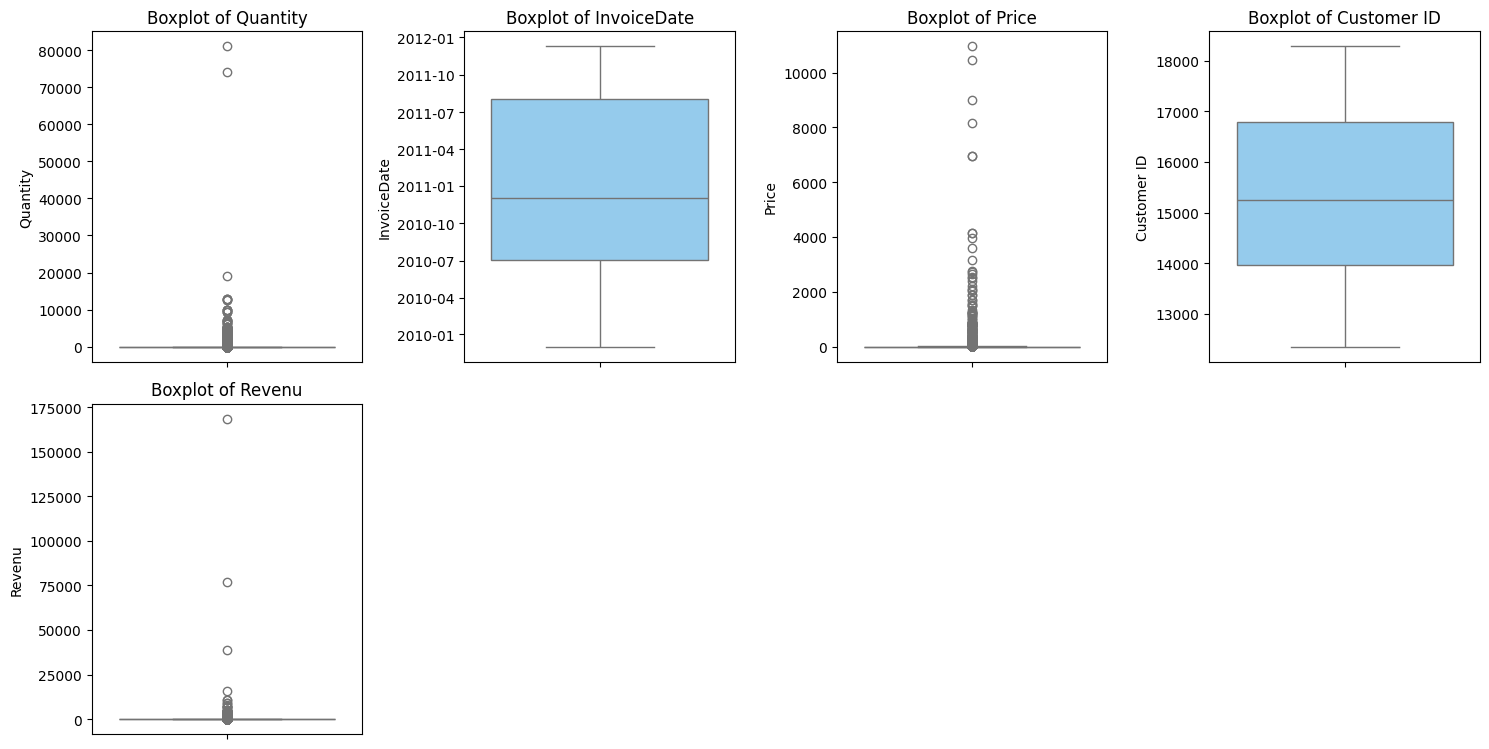

In [277]:
plt.figure(figsize=(15, 15))
for i, col in zip(range(1, len(numerical_columns)+1), numerical_columns):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df[col], color='lightskyblue')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [278]:
df = df[(df['Price'] > 0) & (df['Quantity'] > 0)]

In [279]:
df.info()

<class 'pandas.DataFrame'>
Index: 779425 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779425 non-null  str           
 1   StockCode    779425 non-null  str           
 2   Description  779425 non-null  str           
 3   Quantity     779425 non-null  int64         
 4   InvoiceDate  779425 non-null  datetime64[us]
 5   Price        779425 non-null  float64       
 6   Customer ID  779425 non-null  float64       
 7   Country      779425 non-null  str           
 8   Revenu       779425 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(4)
memory usage: 59.5 MB


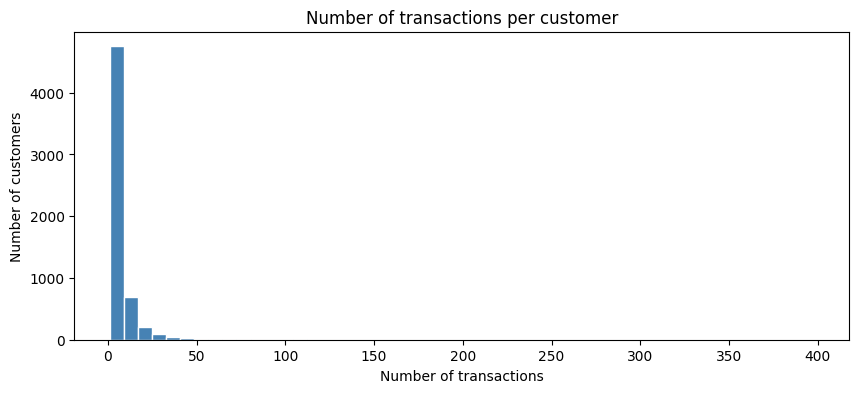

In [280]:
transactions = df.groupby('Customer ID')['Invoice'].nunique()

plt.figure(figsize=(10, 4))
plt.hist(transactions, bins=50, color='steelblue', edgecolor='white')
plt.title("Number of transactions per customer")
plt.xlabel("Number of transactions")
plt.ylabel("Number of customers")
plt.show()

In [281]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Agrégation par client
df = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('Invoice',     'nunique'),
    Revenu   = ('Revenu',     'sum')
).reset_index()

df['AvgOrderValue'] = df['Revenu'] / df['Frequency']

print(df.describe())

        Customer ID      Recency    Frequency         Revenu  AvgOrderValue
count   5878.000000  5878.000000  5878.000000    5878.000000    5878.000000
mean   15315.313542   201.331916     6.289384    2955.904095     385.180841
std     1715.572666   209.338707    13.009406   14440.852688    1214.286459
min    12346.000000     1.000000     1.000000       2.950000       2.950000
25%    13833.250000    26.000000     1.000000     342.280000     176.682500
50%    15314.500000    96.000000     3.000000     867.740000     279.242679
75%    16797.750000   380.000000     7.000000    2248.305000     414.902458
max    18287.000000   739.000000   398.000000  580987.040000   84236.250000


In [282]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5878 entries, 0 to 5877
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Customer ID    5878 non-null   float64
 1   Recency        5878 non-null   int64  
 2   Frequency      5878 non-null   int64  
 3   Revenu         5878 non-null   float64
 4   AvgOrderValue  5878 non-null   float64
dtypes: float64(3), int64(2)
memory usage: 229.7 KB


In [283]:
numerical_columns = [col for col in selector(dtype_exclude=object)(df) if col != 'Customer ID']
categorical_columns = selector(dtype_include=str)(df)
numerical_columns, categorical_columns

(['Recency', 'Frequency', 'Revenu', 'AvgOrderValue'], [])

In [284]:
# Detecting which of the numerical columns have outlier
def detect_outliers_iqr(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    has_outliers = ((data < lower_bound) | (data > upper_bound)).any()

    return has_outliers

In [285]:
for n in numerical_columns:
  print(n, detect_outliers_iqr(df[n]))

Recency False
Frequency True
Revenu True
AvgOrderValue True


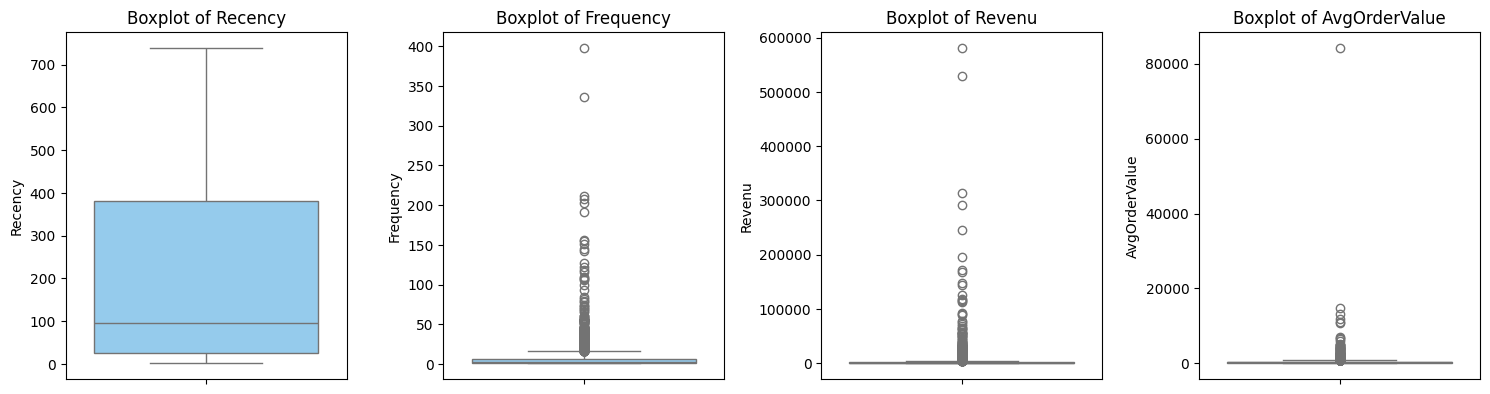

In [286]:
plt.figure(figsize=(15, 15))
for i, col in zip(range(1, len(numerical_columns)+1), numerical_columns):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df[col], color='lightskyblue')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [287]:
def remove_outliers_iqr(df, col, factor=3.0):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

In [288]:
for col in ['Revenu', 'Frequency', 'AvgOrderValue']:
    df = remove_outliers_iqr(df, col)

In [289]:
df.describe()

,Customer ID,Recency,Frequency,Revenu,AvgOrderValue
count,5327.000000,5327.000000,5327.000000,5327.000000,5327.000000
mean,15352.579501,212.665853,4.227708,1307.714534,297.740982
std,1704.835130,210.640221,3.972133,1477.177132,178.187081
min,12347.000000,1.000000,1.000000,2.950000,2.950000
25%,13884.500000,31.000000,1.000000,314.705000,168.795000
50%,15364.000000,117.000000,3.000000,739.200000,262.348571
75%,16831.500000,387.000000,6.000000,1722.790000,379.190000
max,18287.000000,739.000000,21.000000,7956.460000,1045.022500


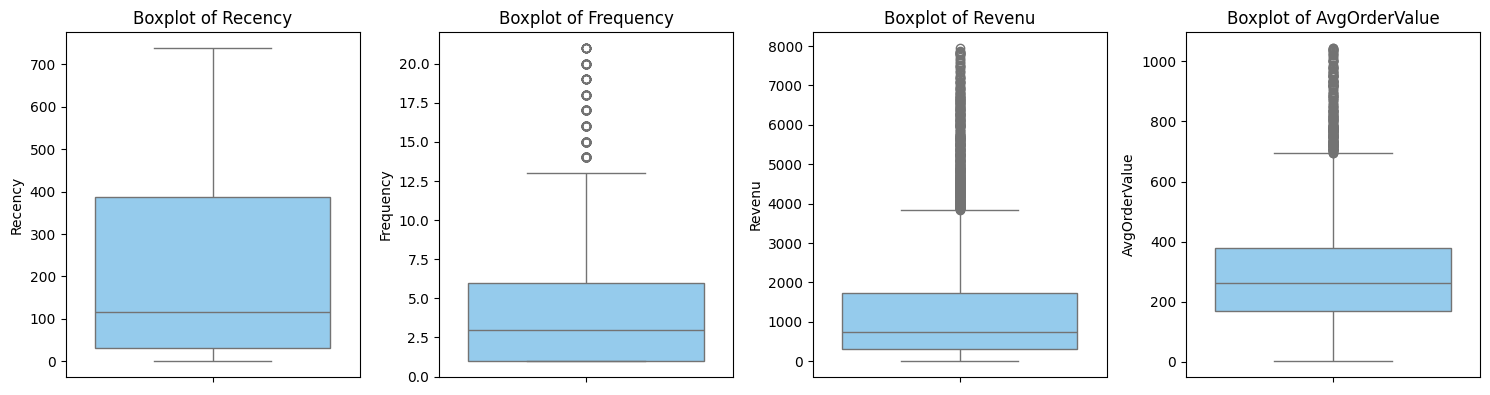

In [290]:
plt.figure(figsize=(15, 15))
for i, col in zip(range(1, len(numerical_columns)+1), numerical_columns):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df[col], color='lightskyblue')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [291]:
df['Revenu']        = np.log1p(df['Revenu'])
df['Frequency']     = np.log1p(df['Frequency'])
df['AvgOrderValue'] = np.log1p(df['AvgOrderValue'])

In [292]:
# Creating preprocessing pipeline for numerical and categorical features
scaler = RobustScaler()
scaled = scaler.fit_transform(df[numerical_columns])

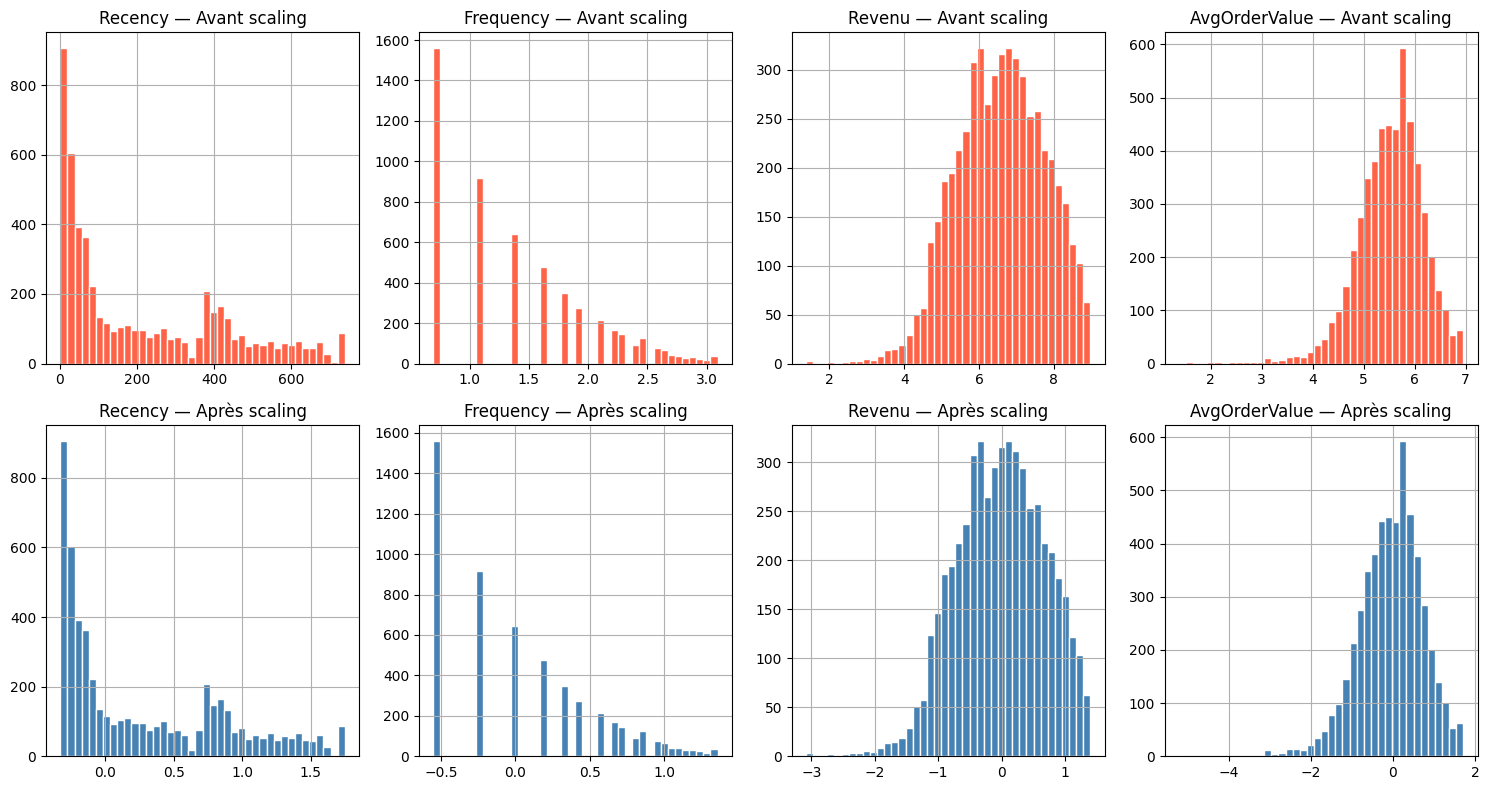

In [293]:
scaled_df = pd.DataFrame(scaled, columns= numerical_columns)

fig, axes = plt.subplots(2, 4, figsize=(15, 8))

cols = numerical_columns

for i, col in enumerate(cols):
    # Avant scaling
    df[col].hist(ax=axes[0][i], bins=40, color='tomato', edgecolor='white')
    axes[0][i].set_title(f'{col} — Avant scaling')
    
    # Après scaling
    scaled_df[col].hist(ax=axes[1][i], bins=40, color='steelblue', edgecolor='white')
    axes[1][i].set_title(f'{col} — Après scaling')

plt.tight_layout()
plt.show()

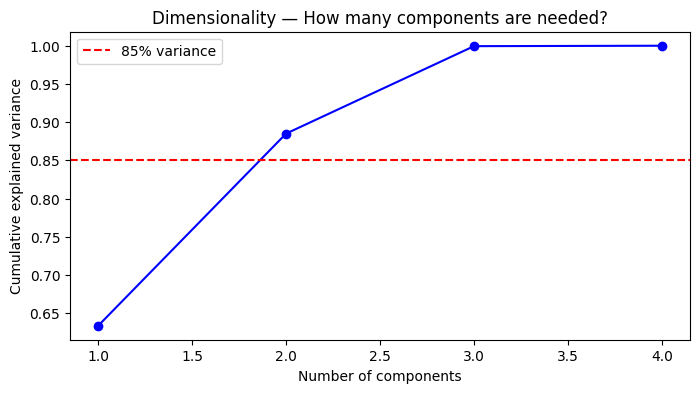

In [294]:
pca = PCA()
pca.fit(scaled)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         np.cumsum(pca.explained_variance_ratio_),
         'bo-')
plt.axhline(y=0.85, color='red', linestyle='--', label='85% variance')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Dimensionality — How many components are needed?")
plt.legend()
plt.show()

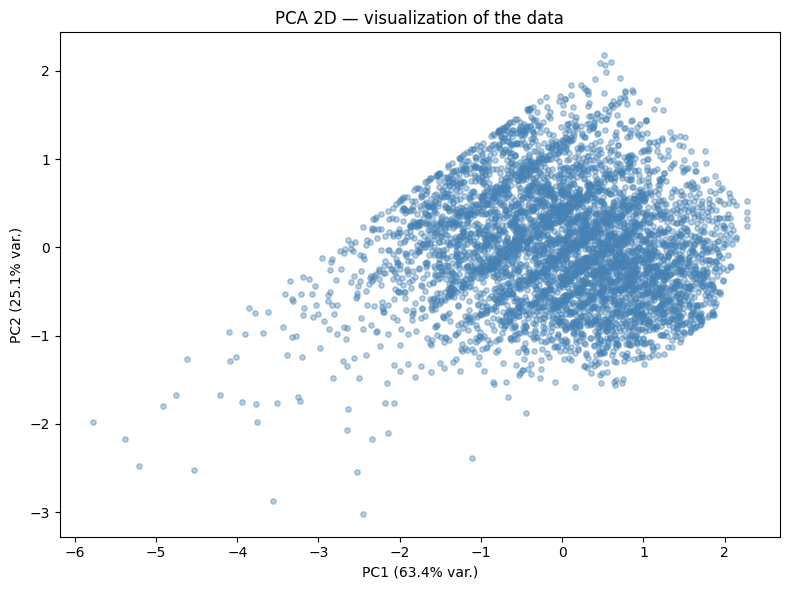

In [295]:
pca2d = PCA(n_components=2)
coords = pca2d.fit_transform(scaled)

plt.figure(figsize=(8, 6))
plt.scatter(coords[:, 0], coords[:, 1], alpha=0.4, s=15, color='steelblue')
plt.xlabel(f'PC1 ({pca2d.explained_variance_ratio_[0]*100:.1f}% var.)')
plt.ylabel(f'PC2 ({pca2d.explained_variance_ratio_[1]*100:.1f}% var.)')
plt.title('PCA 2D — visualization of the data')
plt.tight_layout()
plt.show()


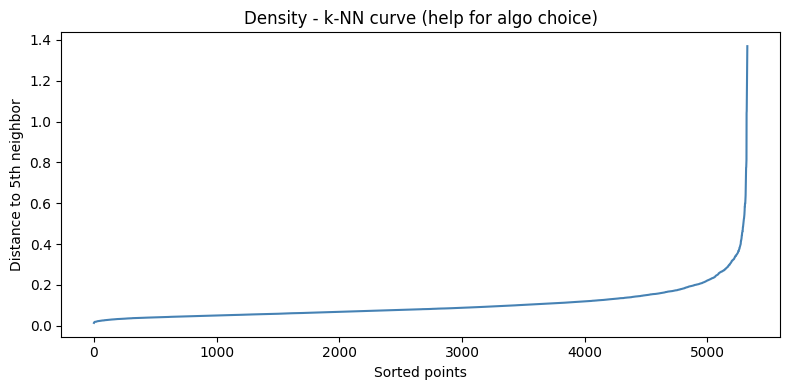

In [296]:
from sklearn.neighbors import NearestNeighbors

# ---------- DENSITY ----------
k = 5
nn = NearestNeighbors(n_neighbors=k)
nn.fit(scaled)
distances, _ = nn.kneighbors(scaled)
knn_distances = np.sort(distances[:, -1]) 

plt.figure(figsize=(8, 4))
plt.plot(knn_distances, color='steelblue')
plt.xlabel("Sorted points")
plt.ylabel(f"Distance to {k}th neighbor")
plt.title("Density - k-NN curve (help for algo choice)")
plt.tight_layout()
plt.show()

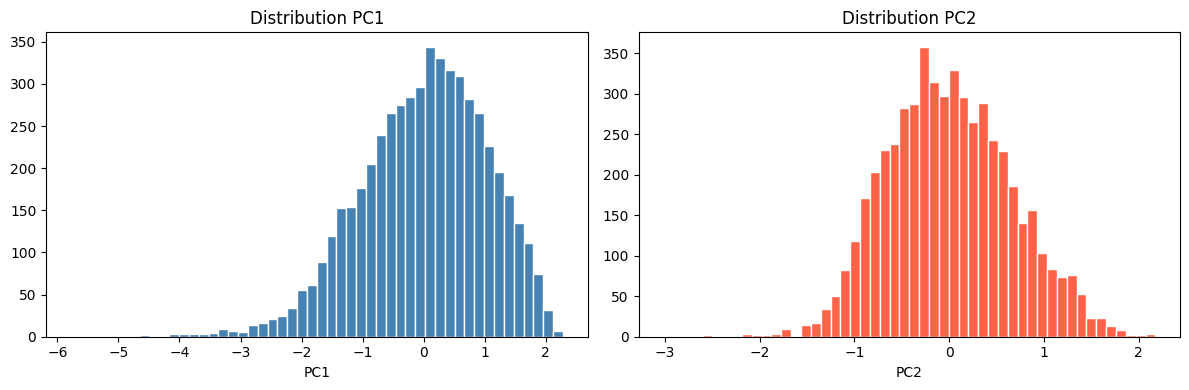

In [297]:
# ---------- SIZE : distribution naturelle via histogramme PC1 ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(coords[:, 0], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title("Distribution PC1")
axes[0].set_xlabel("PC1")

axes[1].hist(coords[:, 1], bins=50, color='tomato', edgecolor='white')
axes[1].set_title("Distribution PC2")
axes[1].set_xlabel("PC2")

plt.tight_layout()
plt.show()

In [298]:
print("=== Statistiques densité k-NN ===")
print(f"  Distance médiane : {np.median(knn_distances):.4f}")
print(f"  Distance max     : {np.max(knn_distances):.4f}")
print(f"  Ratio max/médiane: {np.max(knn_distances)/np.median(knn_distances):.1f}x")
print()
print("Interprétation :")
print("  Courbe progressive → densité uniforme → KMeans ou Agglomeratif")
print("  Courbe avec coude net → densité variable → DBSCAN / HDBSCAN")
print("  Histogrammes PC1/PC2 multimodaux → groupes naturels présents")

=== Statistiques densité k-NN ===
  Distance médiane : 0.0810
  Distance max     : 1.3694
  Ratio max/médiane: 16.9x

Interprétation :
  Courbe progressive → densité uniforme → KMeans ou Agglomeratif
  Courbe avec coude net → densité variable → DBSCAN / HDBSCAN
  Histogrammes PC1/PC2 multimodaux → groupes naturels présents


In [299]:
from sklearn.cluster import KMeans
import kmedoids
K = 4  # justifié par elbow/silhouette

labels_km   = KMeans(n_clusters=K, random_state=42, n_init=10).fit_predict(scaled)
D = pairwise_distances(scaled)
labels_kmed = kmedoids.KMedoids(K, method='fasterpam', random_state=42).fit(D).labels_

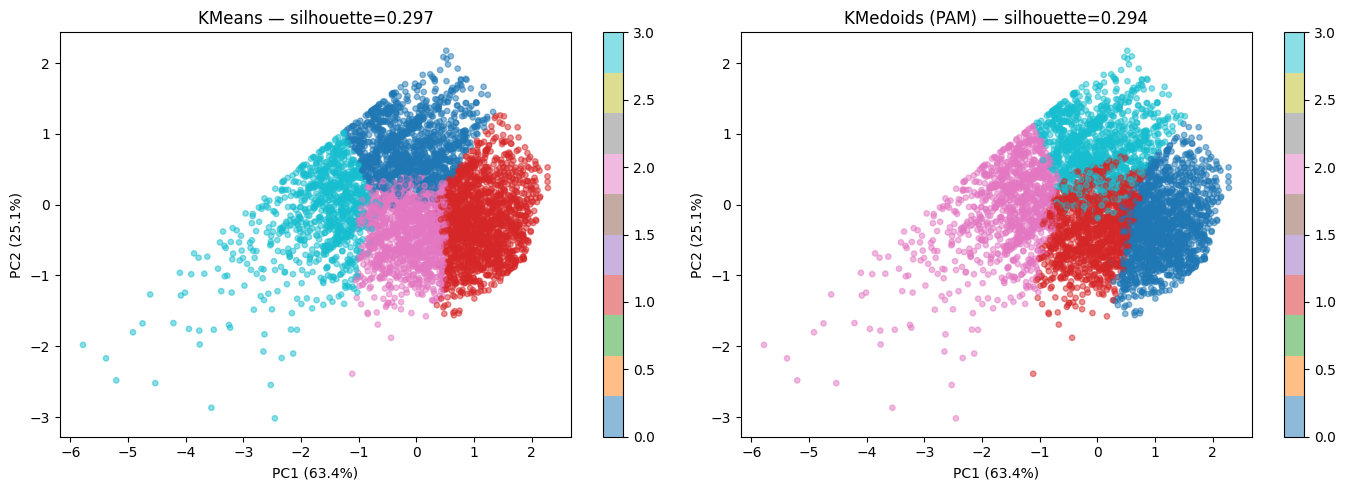

In [300]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, labels, title in zip(axes,
                              [labels_km, labels_kmed],
                              ['KMeans', 'KMedoids (PAM)']):
    sc = ax.scatter(coords[:, 0], coords[:, 1],
                    c=labels, cmap='tab10', alpha=0.5, s=15)
    plt.colorbar(sc, ax=ax)
    sil = silhouette_score(scaled, labels)
    ax.set_title(f'{title} — silhouette={sil:.3f}')
    ax.set_xlabel(f'PC1 ({pca2d.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca2d.explained_variance_ratio_[1]*100:.1f}%)')

plt.tight_layout()
plt.show()


In [301]:
from sklearn.cluster import HDBSCAN

db = HDBSCAN(min_cluster_size=500, min_samples=5)
labels_hdbscan = db.fit_predict(scaled)

/Users/beforma/miniconda3/lib/python3.13/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


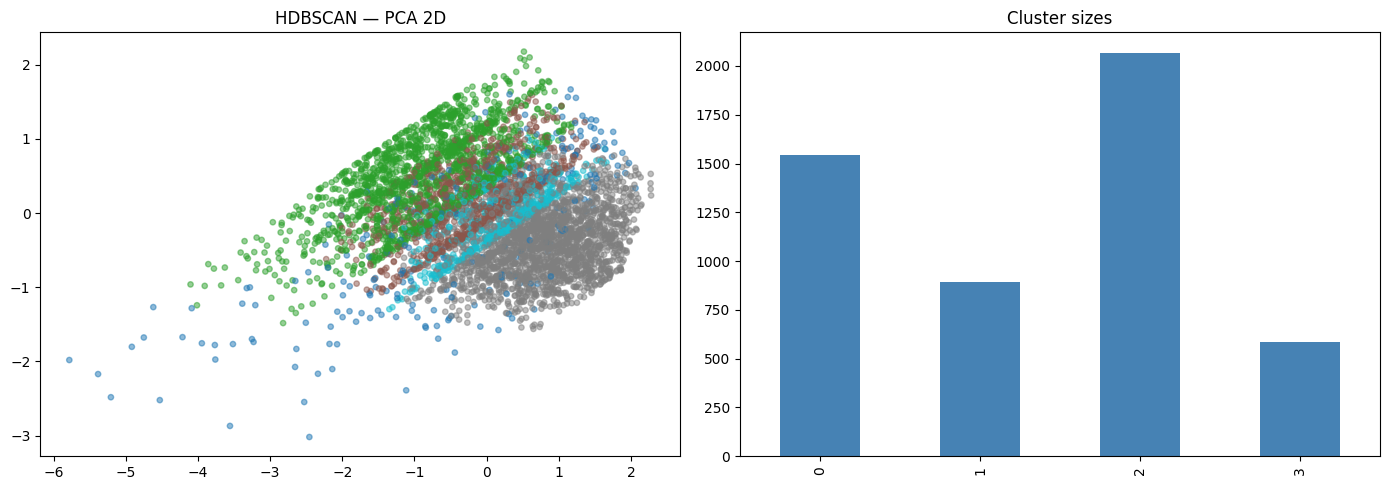

Clusters: 4
Bruit: 233 (4.4%)
Silhouette: 0.0816


In [302]:
mask = labels_hdbscan != -1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(coords[:, 0], coords[:, 1], c=labels_hdbscan, cmap='tab10', alpha=0.5, s=15)
axes[0].set_title('HDBSCAN — PCA 2D')

pd.Series(labels_hdbscan[mask]).value_counts().sort_index().plot.bar(ax=axes[1], color='steelblue')
axes[1].set_title('Cluster sizes')

plt.tight_layout()
plt.show()

print(f"Clusters: {labels_hdbscan.max() + 1}")
print(f"Bruit: {(~mask).sum()} ({(~mask).mean()*100:.1f}%)")
print(f"Silhouette: {silhouette_score(scaled[mask], labels_hdbscan[mask]):.4f}")

In [306]:
mask = labels_hdbscan != -1

algos = {
    'KMeans'  : labels_km,
    'KMedoids': labels_kmed,
    'HDBSCAN' : labels_hdbscan[mask],
}
X_algos = {
    'KMeans'  : scaled,
    'KMedoids': scaled,
    'HDBSCAN' : scaled[mask],
}

print(f"{'':15} {'Silhouette':>14} {'Davies-Bouldin':>18} {'Calinski-Harabasz':>22}")
for name, lbls in algos.items():
    X = X_algos[name]
    print(f"  {name:13} {silhouette_score(X, lbls):>14.4f} {davies_bouldin_score(X, lbls):>18.4f} {calinski_harabasz_score(X, lbls):>22.2f}")

pairs = [('KMeans', 'KMedoids'), ('KMeans', 'HDBSCAN'), ('KMedoids', 'HDBSCAN')]
print(f"{'Paire':>25} {'ARI':>8} {'NMI':>8} {'V-measure':>13}")
for a, b in pairs:
    ref = algos[a]
    cmp = algos[b]
    n   = min(len(ref), len(cmp))
    hom, com, vme = homogeneity_completeness_v_measure(ref[:n], cmp[:n])
    ari = adjusted_rand_score(ref[:n], cmp[:n])
    nmi = normalized_mutual_info_score(ref[:n], cmp[:n])
    print(f"  {a} vs {b:>10} {ari:>8.4f} {nmi:>8.4f} {vme:>13.4f}")

                    Silhouette     Davies-Bouldin      Calinski-Harabasz
  KMeans                0.2972             1.1048                2963.41
  KMedoids              0.2941             1.1208                2901.82
  HDBSCAN               0.0816             3.0751                1172.43
                    Paire      ARI      NMI     V-measure
  KMeans vs   KMedoids   0.7597   0.7294        0.7294
  KMeans vs    HDBSCAN   0.0001   0.0004        0.0004
  KMedoids vs    HDBSCAN  -0.0003   0.0003        0.0003
